In [1]:
import torch
from utils import *

device = "cpu"
if torch.cuda.is_available():
    device = torch.device("cuda:0")
print(f"Running on device {device}")

fix_random(42)

Running on device cuda:0


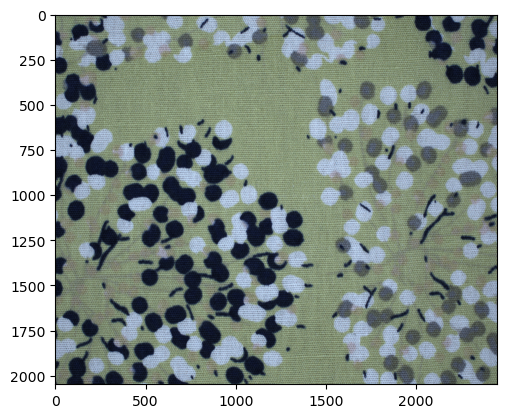

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(
    "/media/gio/HDD/PythonProjects/CarpetAnomalyDetection/fabric/train/good/000_regular.png",
    cv2.IMREAD_COLOR_RGB,
)
plt.imshow(img)
plt.show()

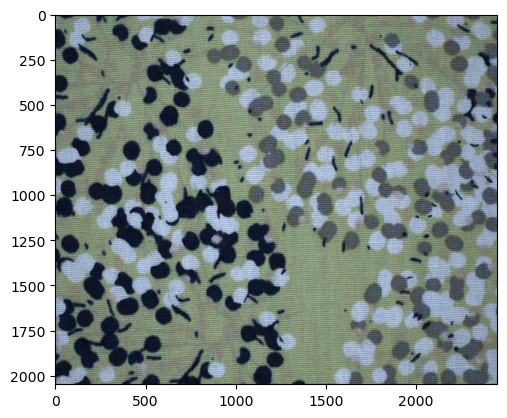

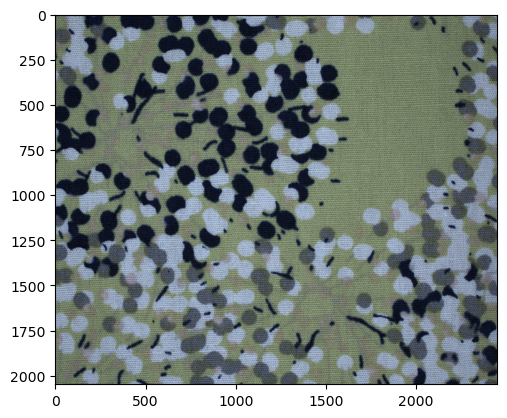

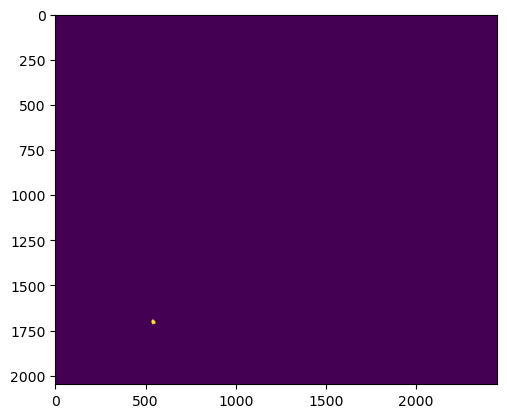

In [ ]:
from torchvision.transforms import v2

transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_set = FabricDataset("./fabric/", "train", transform)

img, _, _ = train_set[1]
img = v2.functional.to_pil_image(img)
plt.imshow(img)
plt.show()
test_set = FabricDataset("./fabric/", "test", transform)

img, _, mask = test_set[-1]
img = v2.functional.to_pil_image(img)
plt.imshow(img)
plt.show()
plt.imshow(mask)
plt.show()

In [ ]:
from cae import ConvolutionalAutoEncoder
from torchinfo import summary

cae = ConvolutionalAutoEncoder(3)
summary(cae)

Layer (type:depth-idx)                        Param #
ConvolutionalAutoEncoder                      --
├─Conv2d: 1-1                                 448
├─Sequential: 1-2                             --
│    └─EncoderBlock: 2-1                      --
│    │    └─Conv2d: 3-1                       4,640
│    │    └─BatchNorm2d: 3-2                  64
│    │    └─Conv2d: 3-3                       9,248
│    │    └─BatchNorm2d: 3-4                  64
│    │    └─ReLU: 3-5                         --
│    │    └─Sequential: 3-6                   608
│    └─EncoderBlock: 2-2                      --
│    │    └─Conv2d: 3-7                       18,496
│    │    └─BatchNorm2d: 3-8                  128
│    │    └─Conv2d: 3-9                       36,928
│    │    └─BatchNorm2d: 3-10                 128
│    │    └─ReLU: 3-11                        --
│    │    └─Sequential: 3-12                  2,240
│    └─EncoderBlock: 2-3                      --
│    │    └─Conv2d: 3-13                   